In [6]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [39]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())
# print(df.tail())
# print(df.columns)
# print(df.shape)
# print(df.info())
# print(df.describe())
# print(df.columns)

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [40]:
print(df.isnull().sum()) #check missing values
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median()) # handling missing data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [41]:
df.drop("customerID",axis=1,inplace = True,errors = "ignore") #remove useless column
df["Churn"] = df["Churn"].astype(str).str.strip()
print(df["Churn"].unique()) #clean target column

['No' 'Yes']


Churn
No     5174
Yes    1869
Name: count, dtype: int64


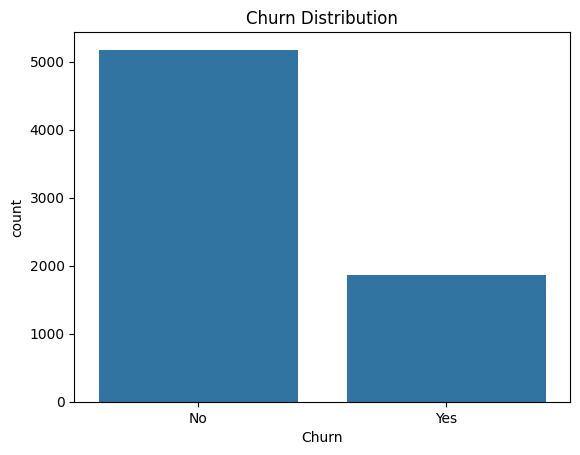

In [43]:
print(df["Churn"].value_counts())
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

In [ ]:
sns.histplot(df["tenure"])
plt.title("Tenure Distribution")
plt.show()
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

In [44]:
df["AvgChargePerMonth"] = (df["TotalCharges"] / (df["tenure"] + 1))
df["LongTermCustomer"] = (df["tenure"] > 24).astype(int)

In [45]:
df["Churn"] = df["Churn"].map({"Yes": 1,"No": 0})
# remove rows ONLY if target failed mapping
df = df.dropna(subset=["Churn"])
# convert to int
df["Churn"] = df["Churn"].astype(int)
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [49]:
X = df.drop("Churn", axis=1)
y = df["Churn"]
print(X.shape)
print(y.shape)

(7043, 21)
(7043,)


In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)


(5634, 21)
(1409, 21)


In [51]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns
print("\nCategorical Columns:")
print(categorical_cols)
print("\nNumerical Columns:")
print(numerical_cols)


Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Numerical Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'AvgChargePerMonth', 'LongTermCustomer'],
      dtype='object')


In [52]:
# preprocessing
from sklearn.preprocessing import(OneHotEncoder,StandardScaler)
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([(
        "num",
        StandardScaler(),
        numerical_cols
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_cols
    )
])

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        RandomForestClassifier(random_state=42,class_weight="balanced")
    )
])


In [56]:
pipeline.fit(X_train, y_train) #train model
predictions = pipeline.predict(X_test) #predict

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print("\nRANDOM FOREST RESULTS\n")
print("Accuracy:")
print(accuracy_score(y_test, predictions))
print("\nPrecision:")
print(precision_score(y_test, predictions))
print("\nRecall:")
print(recall_score(y_test, predictions))
print("\nF1 Score:")
print(f1_score(y_test, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))


RANDOM FOREST RESULTS

Accuracy:
0.7799858055358411

Precision:
0.6126760563380281

Recall:
0.46524064171123

F1 Score:
0.5288753799392097

Confusion Matrix:
[[925 110]
 [200 174]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



In [58]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)
probs = pipeline.predict_proba(X_test)
positive_probs = probs[:, 1]
auc = roc_auc_score(
    y_test,
    positive_probs
)
print("\nROC AUC SCORE:")
print(auc)


ROC AUC SCORE:
0.8191092510785605


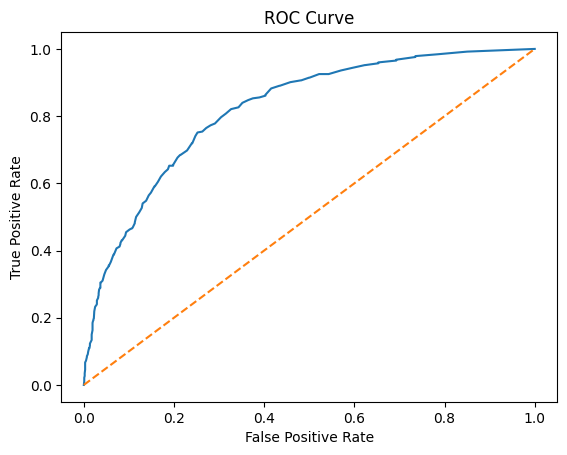

In [59]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    positive_probs
)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [60]:
from sklearn.model_selection import GridSearchCV
params = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [3, 5, 10],
    "model__min_samples_split": [2, 5]
}
grid = GridSearchCV(
    pipeline,
    params,
    cv=3,
    scoring="f1"
)
grid.fit(X_train, y_train)
print("\nBEST PARAMETERS:")
print(grid.best_params_)



BEST PARAMETERS:
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 50}


In [62]:
best_model = grid.best_estimator_

In [63]:
final_predictions = best_model.predict(X_test)
print("\nFINAL MODEL RESULTS\n")
print(
    classification_report(
        y_test,
        final_predictions
    )
)


FINAL MODEL RESULTS

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1035
           1       0.54      0.72      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409



In [64]:
joblib.dump(
    best_model,
    "churn_model.pkl"
)
print("\nModel Saved Successfully!")


Model Saved Successfully!


In [65]:
loaded_model = joblib.load("churn_model.pkl")

In [66]:
sample = X_test.iloc[[0]]
sample_prediction = loaded_model.predict(sample)
sample_probability = loaded_model.predict_proba(sample)
print("\nSample Prediction:")
print(sample_prediction)
print("\nPrediction Probability:")
print(sample_probability)


Sample Prediction:
[0]

Prediction Probability:
[[0.97519033 0.02480967]]


In [75]:
from xgboost import XGBClassifier
xgb_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    (
        "model",
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
    )
])

In [76]:
xgb_pipeline.fit(X_train, y_train)
xgb_predictions = xgb_pipeline.predict(X_test)

In [77]:
print("\nXGBOOST RESULTS\n")
print("Accuracy:")
print(accuracy_score(y_test, xgb_predictions))
print("\nPrecision:")
print(precision_score(y_test, xgb_predictions))
print("\nRecall:")
print(recall_score(y_test, xgb_predictions))
print("\nF1 Score:")
print(f1_score(y_test, xgb_predictions))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_predictions
    )
)


XGBOOST RESULTS

Accuracy:
0.7849538679914834

Precision:
0.6134185303514377

Recall:
0.5133689839572193

F1 Score:
0.5589519650655022

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.51      0.56       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [78]:
xgb_probs = xgb_pipeline.predict_proba(X_test)
xgb_positive_probs = xgb_probs[:, 1]
xgb_auc = roc_auc_score(
    y_test,
    xgb_positive_probs
)
print("\nXGBOOST ROC AUC SCORE:")
print(xgb_auc)


XGBOOST ROC AUC SCORE:
0.8177736443721098


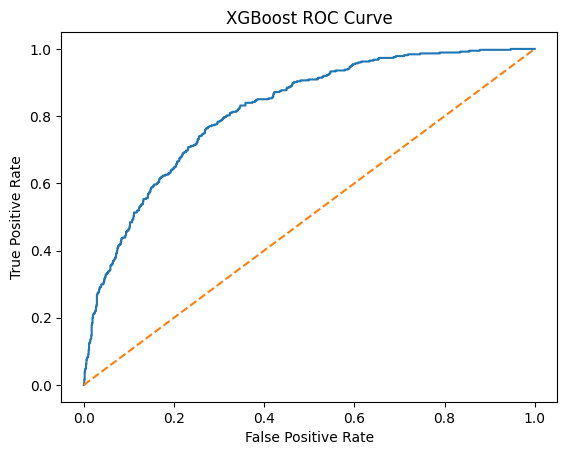

In [79]:
xgb_fpr, xgb_tpr, xgb_thresholds = roc_curve(y_test,xgb_positive_probs)
plt.plot(xgb_fpr, xgb_tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.show()

In [80]:
xgb_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.01, 0.1]
}
xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=3,
    scoring="f1"
)
xgb_grid.fit(X_train, y_train)
print("\nBEST XGBOOST PARAMETERS:")
print(xgb_grid.best_params_)


BEST XGBOOST PARAMETERS:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}


In [81]:
best_xgb_model = xgb_grid.best_estimator_

In [82]:
best_xgb_predictions = best_xgb_model.predict(X_test)
print("\nBEST XGBOOST RESULTS\n")
print(
    classification_report(
        y_test,
        best_xgb_predictions
    )
)



BEST XGBOOST RESULTS

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [83]:
joblib.dump(
    best_xgb_model,
    "xgboost_churn_model.pkl"
)
print("\nXGBoost Model Saved Successfully!")



XGBoost Model Saved Successfully!


In [88]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 31.9 MB/s eta 0:00:00


In [91]:
%%writefile app.py
import streamlit as st

st.title("Hello Streamlit")
st.write("App is working")

Overwriting app.py


In [92]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("xgboost_churn_model.pkl")

st.title("Customer Churn Prediction System")

tenure = st.slider("Tenure", 0, 72, 12)

monthly = st.number_input(
    "Monthly Charges",
    value=50.0
)

total = st.number_input(
    "Total Charges",
    value=500.0
)

contract = st.selectbox(
    "Contract",
    ["Month-to-month", "One year", "Two year"]
)

input_df = pd.DataFrame({
    "tenure": [tenure],
    "MonthlyCharges": [monthly],
    "TotalCharges": [total],
    "Contract": [contract]
})

if st.button("Predict"):
    st.write("Prediction running...")

Overwriting app.py


In [94]:
readme_content = """# Customer Churn Prediction System

## Overview

This project predicts whether a telecom customer is likely to leave the service (churn) using Machine Learning algorithms.

The system analyzes customer behavior, billing information, internet services, contract types, and account details to identify customers at risk of churn.

This is a complete end-to-end Machine Learning project including:
- data cleaning
- exploratory data analysis
- feature engineering
- preprocessing pipelines
- model training
- hyperparameter tuning
- evaluation metrics
- model saving
- XGBoost implementation

---

## Problem Statement

Customer churn is a major business problem in telecom companies because losing customers directly impacts revenue and growth.

The goal of this project is to predict customer churn early so businesses can improve retention strategies and reduce customer loss.

---

## Dataset

Dataset Used:
Telco Customer Churn Dataset

Source:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

---

## Features Used

### Customer Information
- gender
- SeniorCitizen
- Partner
- Dependents

### Service Information
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies

### Billing Information
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges

### Target Variable
- Churn

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- Joblib

---

## Machine Learning Workflow

### 1. Data Cleaning
- Removed customerID column
- Converted TotalCharges to numeric
- Handled missing values

### 2. Exploratory Data Analysis
Performed:
- churn distribution analysis
- tenure analysis
- monthly charges visualization
- customer behavior analysis

### 3. Feature Engineering
Created custom features:
- AvgChargePerMonth
- LongTermCustomer

### 4. Data Preprocessing
Used:
- OneHotEncoding
- StandardScaler
- ColumnTransformer
- Pipeline preprocessing

### 5. Machine Learning Models
Implemented:
- Random Forest Classifier
- XGBoost Classifier

### 6. Hyperparameter Tuning
Used:
- GridSearchCV
- cross-validation

### 7. Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report
- ROC Curve

---

## Project Results

The project successfully predicted customer churn using advanced machine learning techniques.

### Random Forest
- strong classification performance
- balanced handling of churn classes
- robust feature learning

### XGBoost
- improved prediction capability
- better optimization
- high ROC-AUC performance

The models identified important churn-driving factors such as:
- contract type
- monthly charges
- internet services
- tenure

---

## Feature Engineering

Custom features created:

### AvgChargePerMonth
Average customer spending behavior.

### LongTermCustomer
Identifies customers with long service duration.

---

## Hyperparameter Tuning

GridSearchCV was used for:
- optimal tree depth
- number of estimators
- learning rate optimization
- split condition optimization

This improved overall model performance.

---

## Model Saving

Trained models were saved using Joblib:
- churn_model.pkl
- xgboost_churn_model.pkl

This allows deployment without retraining.
"""
with open("README.md", "w") as f:
    f.write(readme_content)